# Coffee Bean Sales Analysis


Data Preparation

In [382]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [383]:
orders = pd.read_excel(r'C:\Data_analyst\SECIND_PROJECT\Raw Data.xlsx', sheet_name= 'orders')
customers = pd.read_excel(r'C:\Data_analyst\SECIND_PROJECT\Raw Data.xlsx', sheet_name= 'customers')
products = pd.read_excel(r'C:\Data_analyst\SECIND_PROJECT\Raw Data.xlsx', sheet_name= 'products')

In [384]:
orders.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Coffee Type,Roast Type,Size,Unit Price,Sales
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [385]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       1000 non-null   object        
 1   Order Date     1000 non-null   datetime64[ns]
 2   Customer ID    1000 non-null   object        
 3   Product ID     1000 non-null   object        
 4   Quantity       1000 non-null   int64         
 5   Customer Name  0 non-null      float64       
 6   Email          0 non-null      float64       
 7   Country        0 non-null      float64       
 8   Coffee Type    0 non-null      float64       
 9   Roast Type     0 non-null      float64       
 10  Size           0 non-null      float64       
 11  Unit Price     0 non-null      float64       
 12  Sales          0 non-null      float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(3)
memory usage: 101.7+ KB


In [386]:
orders.isna().sum()

Order ID            0
Order Date          0
Customer ID         0
Product ID          0
Quantity            0
Customer Name    1000
Email            1000
Country          1000
Coffee Type      1000
Roast Type       1000
Size             1000
Unit Price       1000
Sales            1000
dtype: int64

In [387]:
customers.head()

,Customer ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card
0,17670-51384-MA,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes
1,73342-18763-UW,Piotr Bote,pbote1@yelp.com,+353 (913) 396-4653,2112 Ridgeway Hill,Crumlin,Ireland,D6W,No
2,21125-22134-PX,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes
3,71253-00052-RN,Dene Azema,dazema3@facebook.com,+1 (217) 418-0714,27 Maywood Place,Springfield,United States,62711,Yes
4,23806-46781-OU,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No


In [388]:
customers.isna().sum()

Customer ID         0
Customer Name       0
Email             204
Phone Number      130
Address Line 1      0
City                0
Country             0
Postcode            0
Loyalty Card        0
dtype: int64

In [389]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     1000 non-null   object
 1   Customer Name   1000 non-null   object
 2   Email           796 non-null    object
 3   Phone Number    870 non-null    object
 4   Address Line 1  1000 non-null   object
 5   City            1000 non-null   object
 6   Country         1000 non-null   object
 7   Postcode        1000 non-null   object
 8   Loyalty Card    1000 non-null   object
dtypes: object(9)
memory usage: 70.4+ KB


In [390]:
products.head()

,Product ID,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,A-L-0.2,Ara,L,0.2,3.885,1.9425,0.34965
1,A-L-0.5,Ara,L,0.5,7.770,1.5540,0.69930
2,A-L-1,Ara,L,1.0,12.950,1.2950,1.16550
3,A-L-2.5,Ara,L,2.5,29.785,1.1914,2.68065
4,A-M-0.2,Ara,M,0.2,3.375,1.6875,0.30375


In [391]:
products.isna().sum()

Product ID        0
Coffee Type       0
Roast Type        0
Size              0
Unit Price        0
Price per 100g    0
Profit            0
dtype: int64

In [392]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product ID      48 non-null     object 
 1   Coffee Type     48 non-null     object 
 2   Roast Type      48 non-null     object 
 3   Size            48 non-null     float64
 4   Unit Price      48 non-null     float64
 5   Price per 100g  48 non-null     float64
 6   Profit          48 non-null     float64
dtypes: float64(4), object(3)
memory usage: 2.8+ KB


# Data Cleanning 


In [393]:
orders = orders.drop(columns = ['Customer Name',
 'Email',
 'Country',
 'Coffee Type',
 'Roast Type',
 'Size',
 'Unit Price',
 'Sales'])

In [394]:
df = pd.merge(orders, customers , on = 'Customer ID', how = 'left')
df = pd.merge(df, products ,on = 'Product ID' ,how = 'left' )

In [395]:
df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


In [396]:
df = df.rename(columns = {'Order ID'  : 'Order_ID', 
                          'Order Date' : 'Order_Date', 
                          'Customer ID' : 'Customer_ID', 
                          'Product ID' : 'Product_ID', 
                          'Customer Name' : 'Customer_Name', 
                          'Phone Number' : 'Phone_Number', 
                          'Address Line 1' : 'Address_Line_1', 
                          'Loyalty Card' : 'Loyalty_Card', 
                          'Coffee Type' : 'Coffee_Type', 
                          'Roast Type' : 'Roast_Type', 
                          'Unit Price' : 'Unit_Price', 
                          'Price per 100g' : 'Price_per_100g'})

In [397]:
values = {'L' : 'Light', 'M' : 'Medium', 'D' : 'Dark'}
df['Roast_Type'] = df['Roast_Type'].map(values)

# Analysis

Q1. Which coffee type drives the highest sales volume in each market?

In [398]:
result = df.groupby(['Country', 'Coffee_Type'])['Quantity'].sum().sort_values(ascending= False).reset_index()

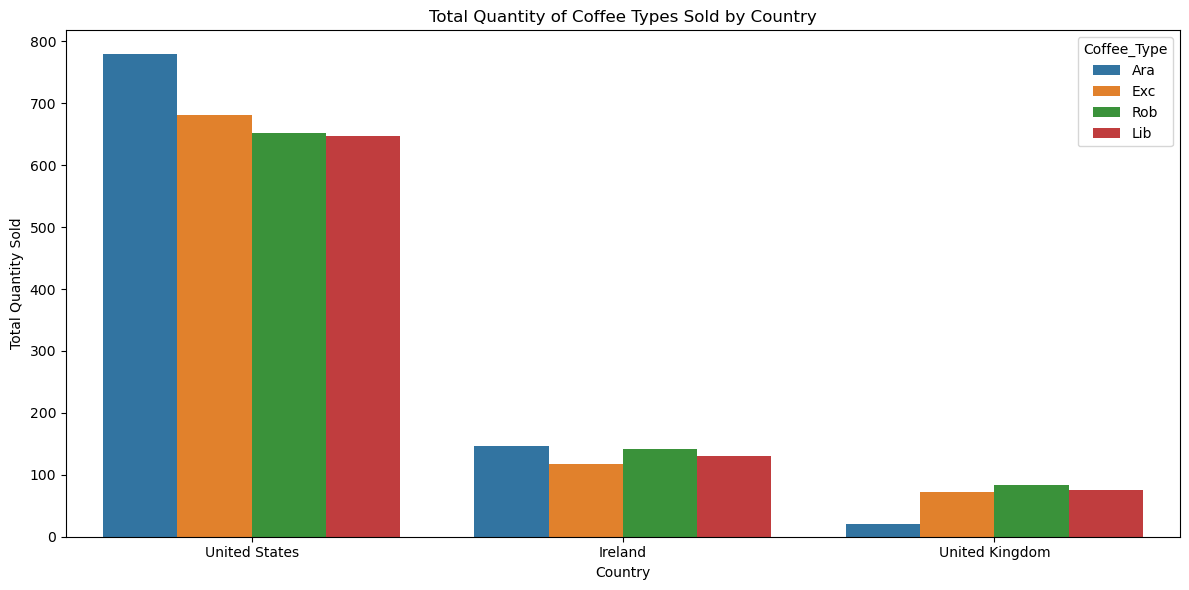

In [399]:
plt.figure(figsize=(12, 6))
sns.barplot(data=result, x='Country', y='Quantity', hue='Coffee_Type')
plt.title('Total Quantity of Coffee Types Sold by Country')
plt.xlabel('Country')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

United States dominates volume across all coffee types — not even close
In the US and Ireland, Ara leads
United Kingdom is the only country where Rob edges out as top seller
All coffee types sell relatively evenly within each country — no coffee type is completely ignored anywhere

Q2. Which country generates the most profit?

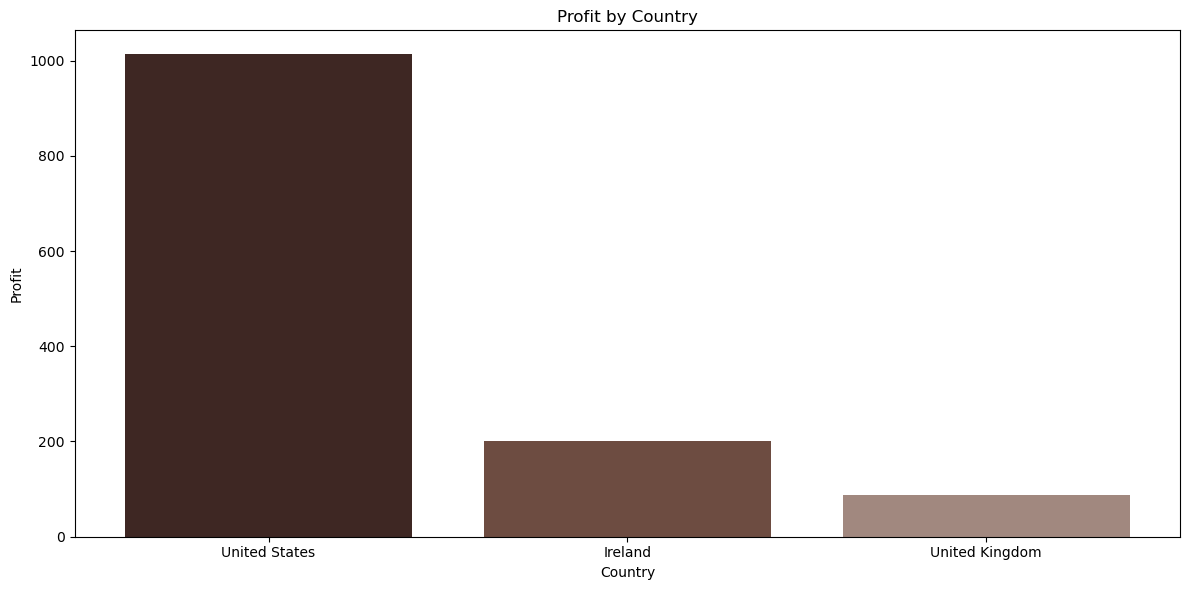

In [400]:
plt.figure(figsize=(12, 6))
result = df.groupby('Country')['Profit'].sum().sort_values(ascending= False).reset_index()
plt.bar(result['Country'], result['Profit'], color = ['#3E2723', '#6D4C41', '#A1887F'])
plt.title('Profit by Country')
plt.xlabel('Country')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

The United States generates significantly more profit ($1,012) 
than Ireland ($202) and the United Kingdom ($86), 
suggesting the business should double down on the US market while exploring 
growth opportunities in underperforming regions.

Q3. Which roast type has the highest unit price?

In [401]:
a = df.groupby('Roast_Type')['Unit_Price'].mean().reset_index()

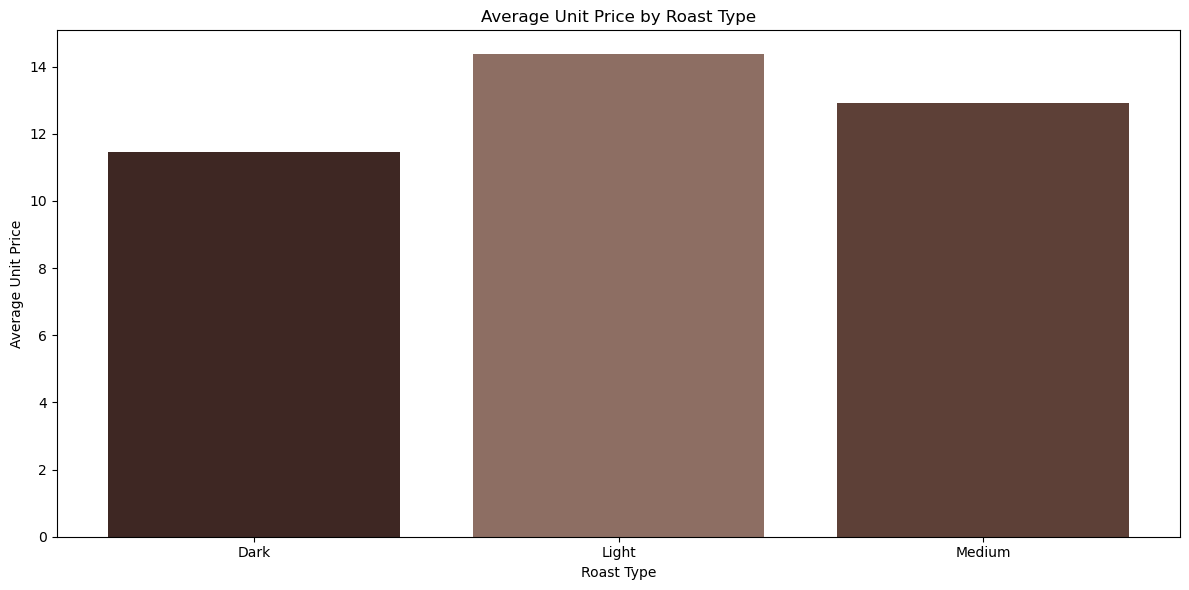

In [402]:
plt.figure(figsize=(12, 6))
plt.bar('Roast_Type', 'Unit_Price', data = a, color = ['#3E2723', '#8D6E63', '#5D4037'])
plt.title('Average Unit Price by Roast Type')
plt.xlabel('Roast Type')
plt.ylabel('Average Unit Price')
plt.tight_layout()
plt.show()

Light roast has the highest average quantity per order (3.69) and highest unit price ($14.30) making it the most profitable roast type — production and marketing should prioritize it.

Q4. Does having a Loyalty Card affect quantity purchased?

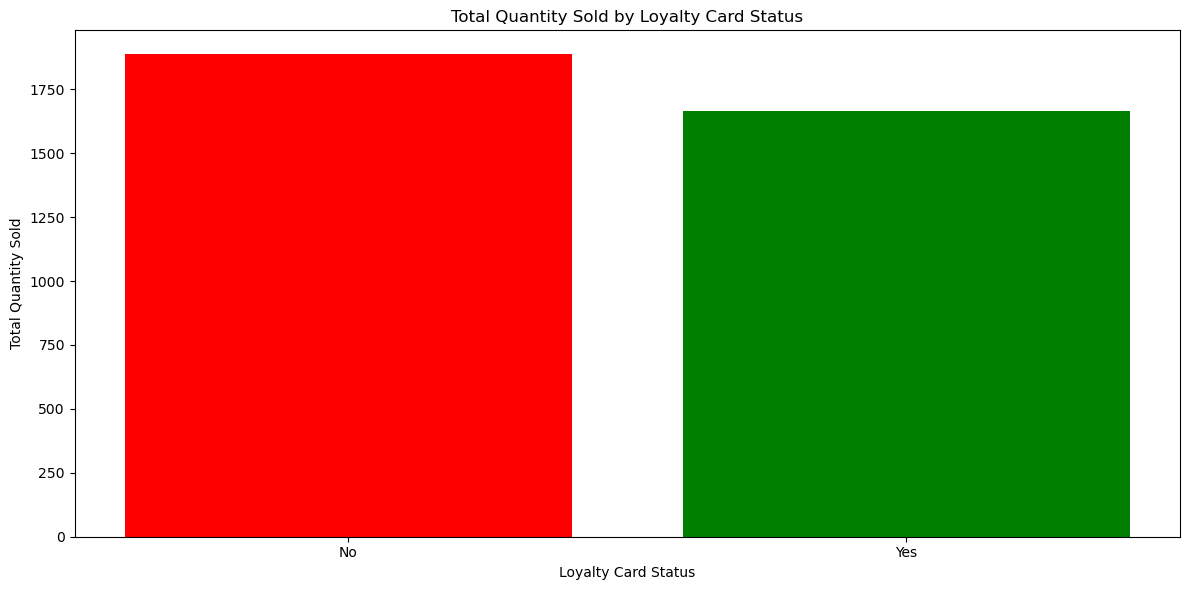

In [403]:
plt.figure(figsize=(12, 6))
loyalty = df.groupby('Loyalty_Card')['Quantity'].sum().reset_index()
plt.bar(loyalty['Loyalty_Card'], loyalty['Quantity'], color=['red', 'green'])
plt.title('Total Quantity Sold by Loyalty Card Status')
plt.xlabel('Loyalty Card Status')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()


Loyalty card holders purchase marginally less per order (3.48 vs 3.62) suggesting the current loyalty program has little impact on purchase frequency and may need redesigning.

In [404]:
corr = df.corr(numeric_only= True)

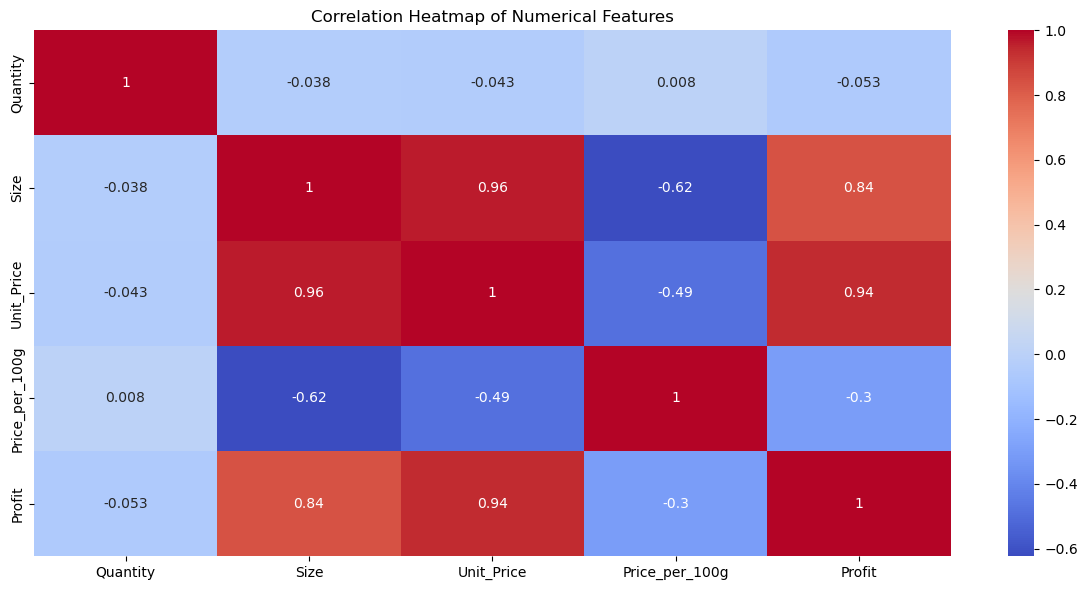

In [405]:
# checking for relationships between columns 

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Q5. Top 10 customers by revenue 

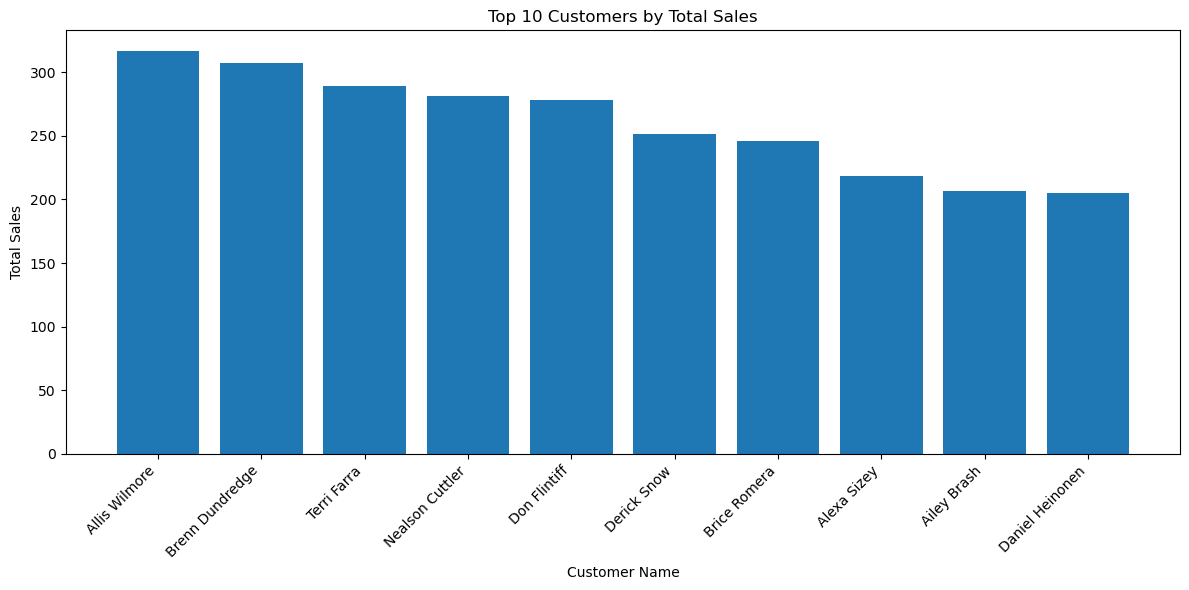

In [406]:
plt.figure(figsize=(12, 6))
df['sales'] = df['Quantity'] * df['Unit_Price']
result = df.groupby(['Customer_ID', 'Customer_Name'])['sales'].sum().sort_values(ascending=False).reset_index().head(10)
plt.bar(result['Customer_Name'], result['sales'])
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer Name') 
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()
plt.show()

7 out of 10 top customers by revenue do not hold a loyalty card, suggesting the business should proactively target high-value customers with loyalty card offers to increase retention.

Q6. Which coffee type has the highest profit margin?

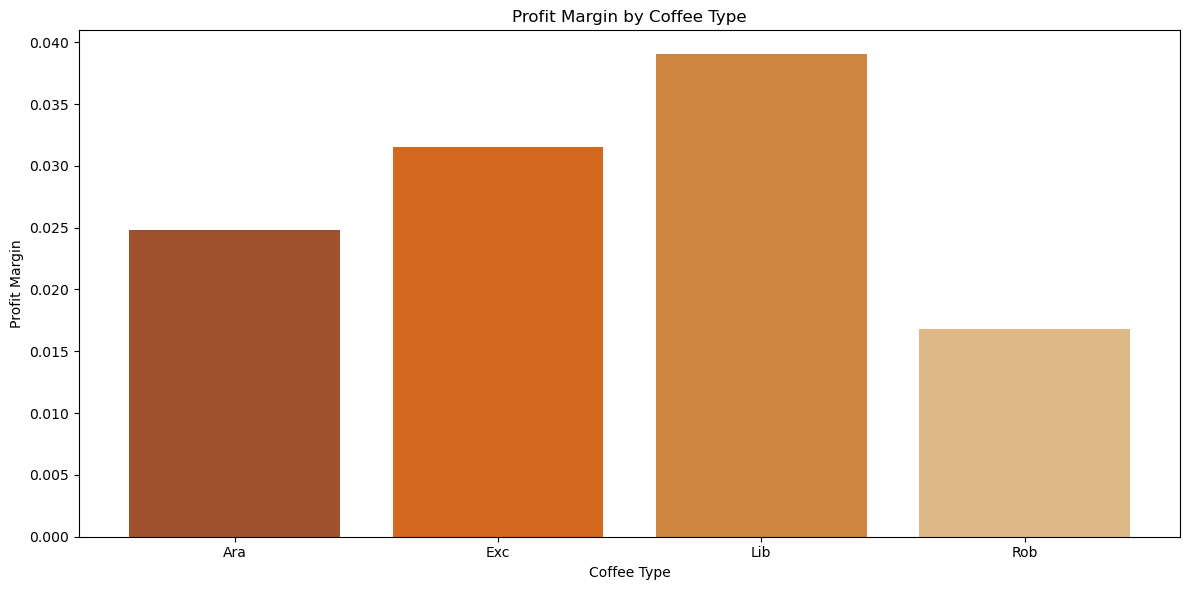

In [407]:
plt.figure(figsize=(12, 6))
grouped = df.groupby('Coffee_Type')[['Profit', 'sales']].sum()
grouped['profit_margine'] = grouped['Profit'] / grouped['sales']
grouped['profit_margine'].sort_values(ascending=False)
plt.bar(grouped.index, grouped['profit_margine'], color = ['sienna', 'chocolate', 'peru', 'burlywood'])
plt.title('Profit Margin by Coffee Type')
plt.xlabel('Coffee Type')
plt.ylabel('Profit Margin')
plt.tight_layout()
plt.show()

Lib has the highest profit margin (3.9%) and second highest total sales ($12,054), making it the most efficient coffee type — the business should prioritize promoting it to maximize profitability.

Q7. What is the total revenue by country AND roast type combined?

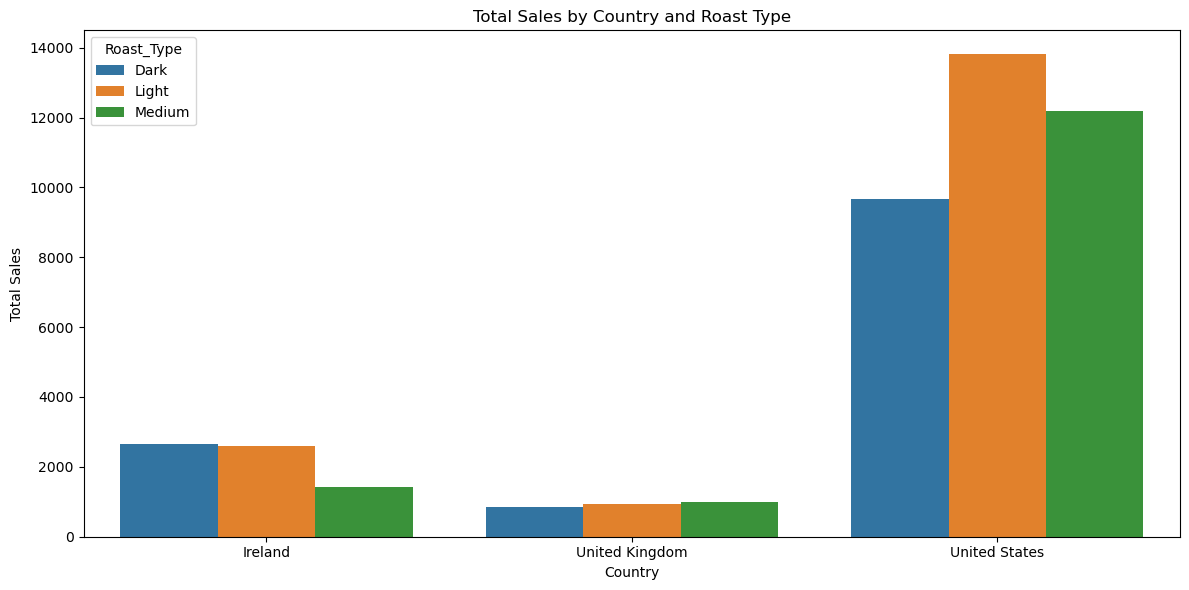

In [408]:
plt.figure(figsize=(12, 6))
data = df.groupby(['Country', 'Roast_Type'])['sales'].sum().reset_index()
sns.barplot(data = data, x = 'Country', y = 'sales', hue = 'Roast_Type')
plt.title('Total Sales by Country and Roast Type')  
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


Light roast maintains strong sales volume despite being the highest priced option, suggesting demand is price inelastic and the business could increase Light roast prices further to improve profit margins.

Q8. Which city has the highest average order value?

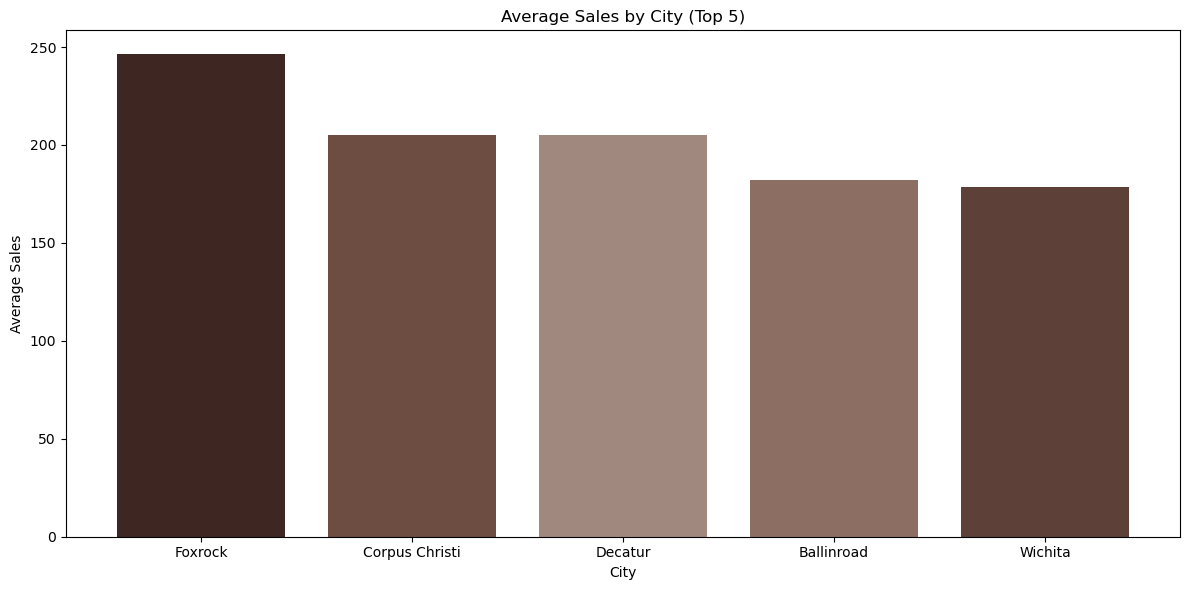

In [409]:
plt.figure(figsize=(12,6))
data = df.groupby(['City', 'Order_ID'])['sales'].sum().reset_index()
data = data.groupby('City')['sales'].mean().sort_values(ascending=False).reset_index().head()
plt.bar(data['City'],data['sales'], color = ['#3E2723', '#6D4C41', '#A1887F', '#8D6E63', '#5D4037'])
plt.title('Average Sales by City (Top 5)')
plt.xlabel('City')  
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

Foxrock has the highest average order value at $246.210, suggesting it contains high-spending customers worth targeting for premium product promotions.

Q9. What is the monthly revenue trend over time?

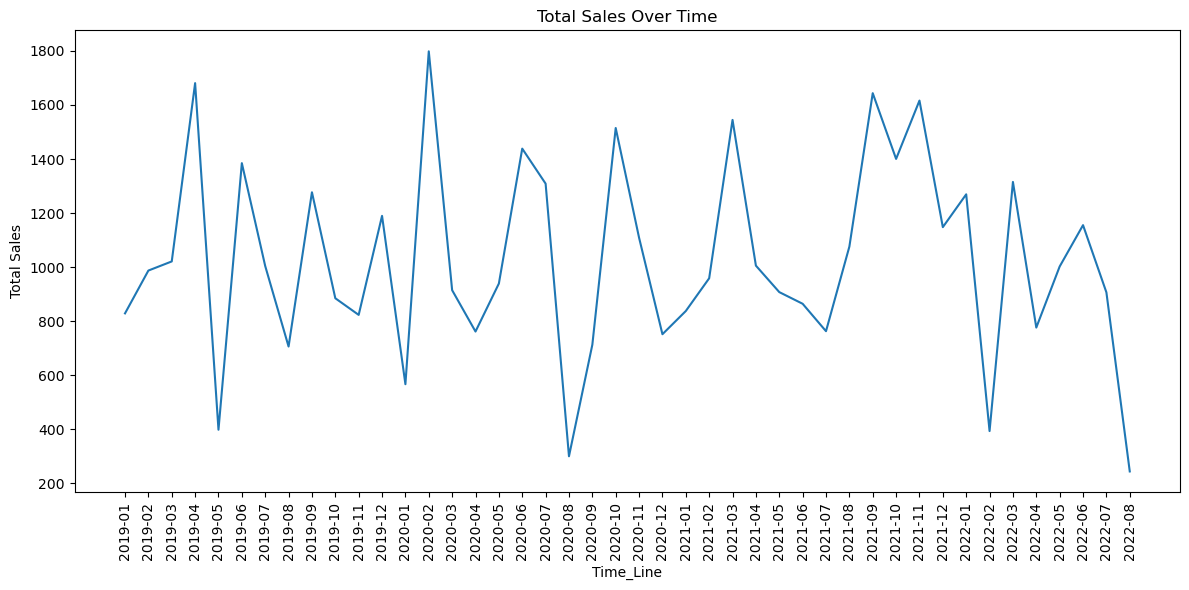

In [410]:
plt.figure(figsize=(12,6))
df['Year_month'] = df['Order_Date'].dt.to_period('M')
data = df.groupby('Year_month')['sales'].sum().reset_index()
plt.plot(data['Year_month'].astype(str), data['sales'])
plt.title('Total Sales Over Time')
plt.xlabel('Time_Line')
plt.ylabel('Total Sales')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

Monthly sales show high volatility with no clear growth trend from 2019-2022. The sharp drop in August 2022 is misleading — the dataset ends mid-month on August 19th and does not represent a full month of sales.

Q10. Which month consistently has the highest sales across all years?

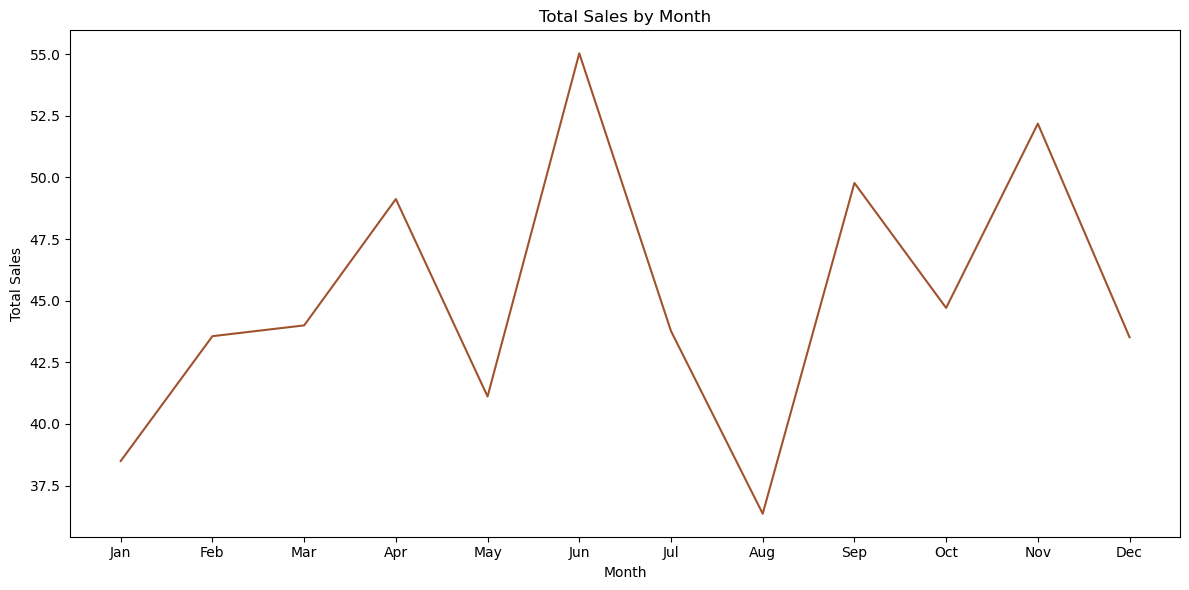

In [411]:
plt.figure(figsize=(12,6))
df['Month'] = df['Order_Date'].dt.to_period('M').dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
data = df.groupby('Month', observed=False)['sales'].mean().reset_index()
plt.plot(data['Month'], data['sales'], color = 'sienna')
plt.title('Total Sales by Month')
plt.xlabel('Month') 
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Best months → June, November (focus & scale)

Worst month → August (fix urgently)

Sales are seasonal → plan strategy accordingly

# KEY FINDINGS: 

1. United States dominates sales so we should focus more on growing this market.
2. Light roast commands the highest price so promoting it can increase revenue.
3. Loyalty card has little impact so the program needs improvement to boost customer purchases
4. Best months → June, November (focus & scale) Worst month → August (fix urgently)  Sales are seasonal → plan strategy accordingly
5. 7 out of 10 top customers by revenue do not hold a loyalty card, suggesting the business should proactively target high-value customers with loyalty card offers to increase retention.